# A paper-inspired grid-world shield for tabular Q-learning

This notebook uses the shared model in `finite_mdp.py` and the synthesis
plumbing in `shielding.py`.  The 5×4 layout is a compact **adaptation**, not an
exact reproduction, of the grid world released with Alshiekh et al., *Safe
Reinforcement Learning via Shielding* (AAAI 2018).

```text
44#.1
..#..
.3g2.
..#..
```

The learner proposes `north`, `east`, `south`, `west`, or `wait`.  The visible
cell is only one state factor: the full model also records whether gate `g` is
blocked and which region is expected next in the ordered tour `1→2→3→4`.

The three numbered sections below are the three steps of the talk: **state the
properties**, **complement them and hand them to Spot**, **solve the safety game
and expose its boundary**.

map:
44#.1
..#..
.3g2.
..#..
physical cells: 17
full product states: 17 cells × 2 gate states × 4 monitor stages = 136


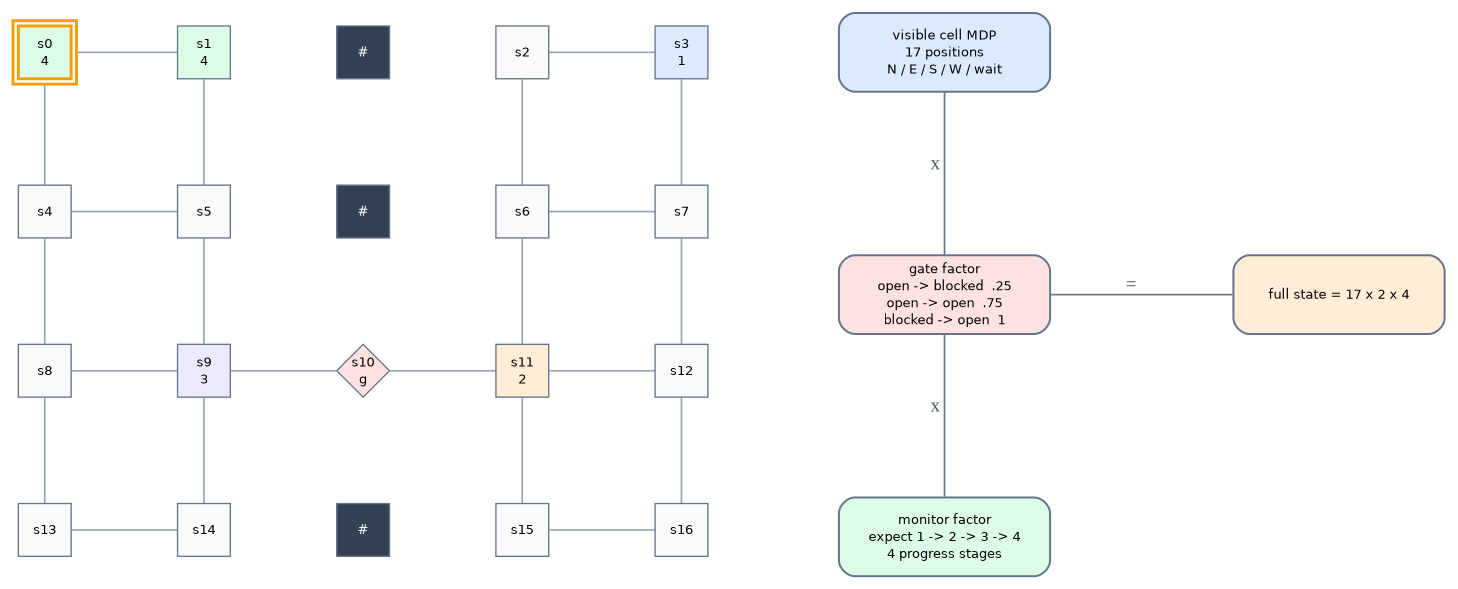

In [1]:
from pathlib import Path

from IPython.display import SVG, Image, display

import acacia_boomslang as ab
import shielding as sh
from finite_mdp import (
    ACTIONS,
    ASSUMPTION,
    GUARANTEE_GLOSS,
    assumed_ltl,
    bare_ltl,
    guarantees,
    paper_gridworld,
    write_artifacts,
)

world = paper_gridworld()
artifacts = write_artifacts(Path("generated"), world)

print("map:")
print("\n".join(world.rows))
print("physical cells:", len(world.physical_states))
print("full product states: 17 cells × 2 gate states × 4 monitor stages =",
      world.product_state_count)
display(Image(filename=str(artifacts["mdp_png"])))

## 1. The properties

Everything the controller must guarantee, named.  These are the same
requirements the talk introduces in ordinary language — legal motion, never
crossing a closed gate, a monitor that advances deterministically, and a tour
that completes over and over — written as LTL over the model's atomic
propositions.

They are long because the cell and stage encodings are binary: `legalStep` alone
spells out, for each of the 17 cells, which cells may follow it.  Length is an
artefact of the encoding, not of the idea.

In [2]:
spec = guarantees(world)

print(f"{'guarantee':16s} {'chars':>7s}   meaning")
for name, clause in spec.items():
    print(f"{name:16s} {len(clause):7d}   {GUARANTEE_GLOSS[name]}")

print(f"\nconjunction of all five  = bare_ltl(), {len(bare_ltl(world))} characters")
print(f"assumption               = {ASSUMPTION}")
print(f"what we actually solve   = ({ASSUMPTION}) -> (the five above)")

# One of them is short enough to read whole, and it is the one everything else
# in this notebook ends up being about.
print(f"\ntourForever = {spec['tourForever']}")
assert assumed_ltl(world) == f"({ASSUMPTION}) -> ({bare_ltl(world)})"

guarantee          chars   meaning
validEncoding       1760   every step names a real cell and a real stage, and the first move leaves the start legally
gateRespected         94   never enter the gate while it is closed
legalStep           6410   each move goes to an adjacent cell
monitorUpdate       9921   the tour monitor advances deterministically
tourForever           19   the ordered tour completes infinitely often

conjunction of all five  = bare_ltl(), 18216 characters
assumption               = G F !blocked
what we actually solve   = (G F !blocked) -> (the five above)

tourForever = (G F tour_complete)


## 2. Complement the formula, then hand it to Spot

Acacia wants an automaton for the **bad** plays, so the specification is negated
on the way in.  In LTL that is the entire operation — one `!` — and
[Spot](https://spot.lre.epita.fr/) does the rest: it parses the formula,
simplifies it, and translates it into an automaton.

Start with a single guarantee, small enough to read every label.

the guarantee, as we wrote it : (G F tour_complete)
negated, which is the whole of : !((G F tour_complete))
as Spot parses and simplifies  : !GFtour_complete


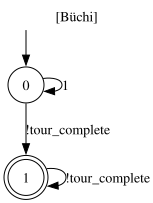

In [3]:
import spot

tour = spec["tourForever"]
print("the guarantee, as we wrote it :", tour)
print("negated, which is the whole of :", sh.negated(tour))
print("as Spot parses and simplifies  :", spot.formula(sh.negated(tour)))

# !(G F p) is F G !p: eventually the tour is never completed again.  This is the
# liveness half of the specification, and the counter the shield carries is
# exactly a bound on how long this automaton may sit in its accepting state.
display(SVG(sh.formula_svg(sh.negated(tour))))

The joint formula gets the same treatment, and comes back a good deal bigger:
27 states over nine atomic propositions.  Its **double circles are the bad
states** — the ones the monitor counts visits to.

Edge labels are dropped here.  Each is a cube over all nine propositions, and
Graphviz widens the drawing to fit them: with labels this automaton lays out
about eleven metres across and is unreadable at any zoom.  Without them it is a
band roughly three times wider than tall, which is also the layout the talk's
animation uses — so this is literally the same picture.

`sh.build_game` is not hiding anything interesting: it is the four Acacia calls
from the talk's code slide — `create_twa` on the negation, the two preprocessing
passes that fix the bound `k`, then `solve_acacia_safety_game`.

bare guarantees realizable:       False
with G F !blocked, realizable at k=16: True
preprocessed UCB states:          27


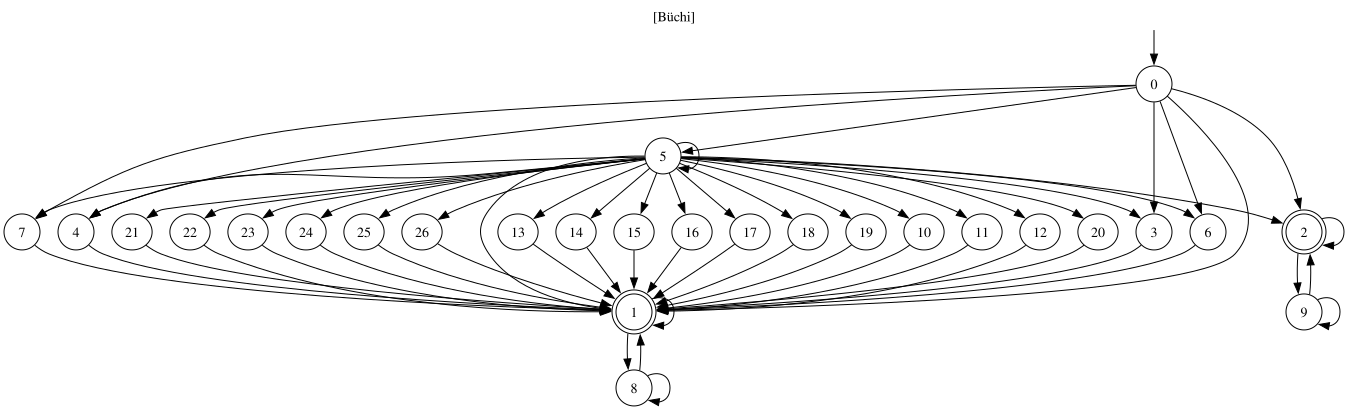

In [4]:
k = 16
bare_game, bare_result = sh.build_game(bare_ltl(world), k)
game_k16, result_k16 = sh.build_game(assumed_ltl(world), k)

print("bare guarantees realizable:      ", bare_result.is_real())
print(f"with {ASSUMPTION}, realizable at k={k}:", result_k16.is_real())
print("preprocessed UCB states:         ", ab.num_states(game_k16))

assert not bare_result.is_real()
assert result_k16.is_real()

display(SVG(sh.ucb_svg(game_k16, labels=False)))

## 3. The safety game, and the boundary it exposes

Bounding the number of visits to those bad states turns the whole specification
into a **safety** game, and safety is the case where staying inside the winning
region is not merely necessary but sufficient.  So the maximally permissive
winning strategy is just the winning region: at each history, every action whose
successor stays inside it.

`WinningRegionShield.allowed` is that set.  It takes an ordinary movement
proposal, encodes the cell, stage and completion bits it induces, and keeps it
exactly when the successor is still winning.

In [5]:
shield_k16 = sh.WinningRegionShield(world, game_k16, result_k16)
game_k20, result_k20 = sh.build_game(assumed_ltl(world), 20)
shield_k20 = sh.WinningRegionShield(world, game_k20, result_k20)

print("k=16 antichain maxima:", len(shield_k16.region))
print("k=20 antichain maxima:", len(shield_k20.region))

state = world.initial_state(blocked=False)
vector = shield_k16.initial()
print("\nat the start cell")
print("  ordinary actions:", list(ACTIONS))
print("  allowed by the shield:", shield_k16.allowed(vector, state))

assert "north" not in shield_k16.allowed(vector, state)
assert "west" not in shield_k16.allowed(vector, state)

k=16 antichain maxima:

 146
k=20 antichain maxima: 146

at the start cell
  ordinary actions: ['north', 'east', 'south', 'west', 'wait']
  allowed by the shield: ['east', 'south', 'wait']


The bound `k` is the one knob.  Both values enforce the same specification;
the larger one simply carries more slack, and the slack is visible as how long
the learner may sit still before the shield insists on a move.

In [6]:
waits_k16 = sh.consecutive_wait_envelope(world, shield_k16)
waits_k20 = sh.consecutive_wait_envelope(world, shield_k20)

print("k=16 allowed after 0 waits:", waits_k16[0])
print("k=16 allowed after 1 wait: ", waits_k16[1])
print("k=20 allowed after 1 wait: ", waits_k20[1])
print("\nmay wait this many steps in a row, k=16 / k=20:",
      len(waits_k16) - 1, "/", len(waits_k20) - 1)

assert len(waits_k16) - 1 == 1
assert len(waits_k20) - 1 == 5
assert len(waits_k20[1]) > len(waits_k16[1])

k=16 allowed after 0 waits: ['east', 'south', 'wait']
k=16 allowed after 1 wait:  ['east', 'south']
k=20 allowed after 1 wait:  ['east', 'south', 'wait']

may wait this many steps in a row, k=16 / k=20: 1 / 5


Drawn on the map, the envelope at the start cell looks like this: north and west
would leave the grid, so the shield excludes them; east, south and wait survive.

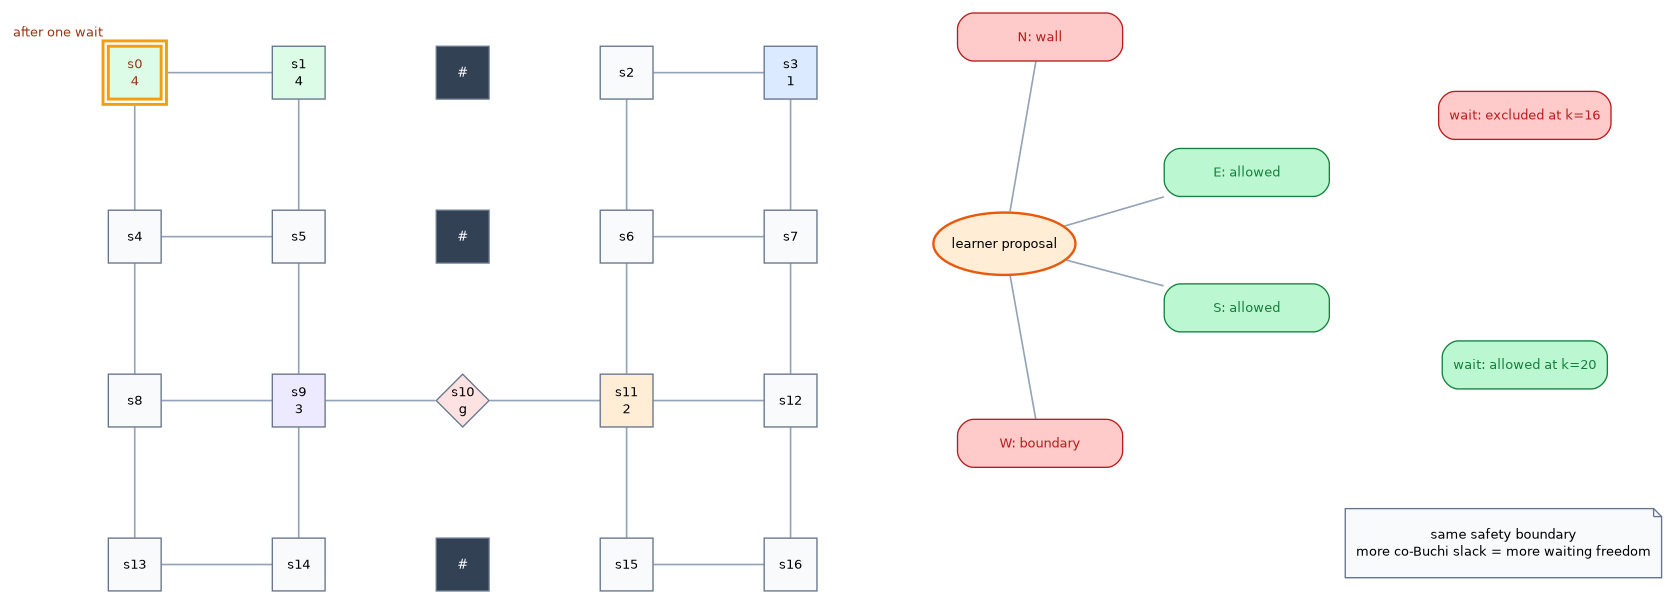

In [7]:
display(Image(filename=str(artifacts["shield_png"])))

## 4. Fixed controller versus permissive shield

A single winning controller and the whole winning region are both correct.  The
difference is how often the learner's own proposal has to be overruled.

In [8]:
fixed_summary = sh.compare_mode(world, shield_k16, "fixed")
permissive_summary = sh.compare_mode(world, shield_k16, "permissive")

print("                         interventions  collisions  tours")
print("fixed controller:       ", fixed_summary)
print("permissive win. region: ", permissive_summary)

assert fixed_summary[1] == permissive_summary[1] == 0
assert permissive_summary[0] < fixed_summary[0]

                         interventions  collisions  tours
fixed controller:        (185, 0, 13)
permissive win. region:  (145, 0, 12)


## 5. Seeded tabular Q-learning behind the shield

The same learner, the same seed, with and without the envelope.  Read the
collision counts, not the returns: this is a correctness demonstration, not a
performance benchmark.

In [9]:
unshielded = sh.train(world, None, seed=23)
shielded = sh.train(world, shield_k16, seed=23)

def final_mean(values, count=40):
    return sum(values[-count:]) / count

print("unshielded collisions:", sum(unshielded["collisions"]))
print("shielded collisions:", sum(shielded["collisions"]))
print("shield interventions:", sum(shielded["interventions"]))
print("completed tours (unshielded / shielded):",
      sum(unshielded["tours"]), "/", sum(shielded["tours"]))
print("mean return, final 40 episodes (unshielded / shielded):",
      round(final_mean(unshielded["reward"]), 3), "/",
      round(final_mean(shielded["reward"]), 3))

assert sum(unshielded["collisions"]) > 0
assert sum(shielded["collisions"]) == 0

unshielded collisions: 750
shielded collisions: 0
shield interventions: 6295
completed tours (unshielded / shielded): 628 / 732
mean return, final 40 episodes (unshielded / shielded): 2.56 / 2.56


### Takeaway

The synthesized object is an action envelope over the full product state.
The temporal specification establishes the boundary; tabular Q-learning ranks
ordinary movement actions inside it, with zero observed shielded collisions.